# Exercise: Trends in IN Snow

In this exercise, we will build on geospatial skills from last week to assemble a dataset of snow observations in Indiana from a global dataset of meteorological observations.  The aim will be to ask whether there are trends in snow in IN.  This exercise will involve automatically downloading data from an external source.  

The source dataset is: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily

There will be several steps involved:

1. Downloading an inventory of all available Global Historical Climatology Network daily (GHCNd) stations
1. Opening that inventory and finding stations within Indiana (hint, use `geopandas` and clipping)
1. Loading all the IN files (*hint*: use a for loop and `pd.read_csv()`, which can load data from a URL)
1. Calculating trends in annual snow totals

The cells below are pre-commented, so you can use them as a form of instruction.  Work with a group, but complete your own notebook and commit it to github.

```{note}
There is a breakpoint in this excercise; you can stop there for today if you want to spend the rest of the time on your final project.  This notebook will need to be completed by the end of finals week.
```

In [1]:
""" Import libraries. """
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs
import geopandas as gpd
import pandas as pd
from tqdm.notebook import tqdm # for a progress bar; you'll need to install tqdm and ipywidgets
import scipy
import datetime as dt

In [2]:
""" Load the inventory file. """

# set the inventory file
inventory_file = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-inventory.txt"

# load the inventory file into a pandas dataframe
inventory_pd = pd.read_fwf(inventory_file, header=None, names=["ID", "LATITUDE", "LONGITUDE", "VARIABLE", "FIRSTYEAR", "LASTYEAR" ])
inventory_pd.head()

,ID,LATITUDE,LONGITUDE,VARIABLE,FIRSTYEAR,LASTYEAR
0,ACW00011604,17.1167,-61.7833,TMAX,1949,1949
1,ACW00011604,17.1167,-61.7833,TMIN,1949,1949
2,ACW00011604,17.1167,-61.7833,PRCP,1949,1949
3,ACW00011604,17.1167,-61.7833,SNOW,1949,1949
4,ACW00011604,17.1167,-61.7833,SNWD,1949,1949


In [3]:
""" Convert the inventory dataframe to a geopandas dataframe. """
inventory_gpd = gpd.GeoDataFrame(inventory_pd, geometry=gpd.points_from_xy(inventory_pd.LONGITUDE, inventory_pd.LATITUDE), crs = "EPSG:4326")

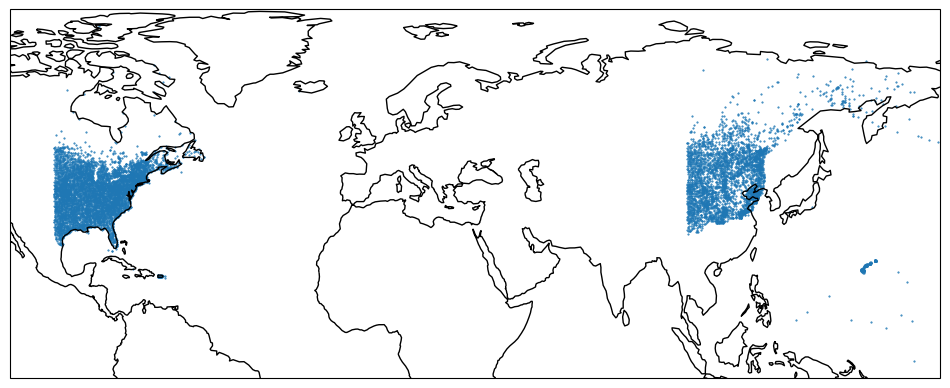

In [4]:
""" Find stations that have at least 50 years of data. """

# find stations that have at least 50 years of data
inventory_50_gpd = inventory_gpd[inventory_gpd.LASTYEAR - inventory_gpd.FIRSTYEAR >= 50]

projection = cartopy.crs.PlateCarree()

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(projection=projection))

# plot the stations that have at least 50 years of SNOW data
inventory_50_gpd[inventory_50_gpd.VARIABLE == "SNOW"].plot(ax = ax, transform = projection,marker = '.', markersize = 1)

ax.coastlines()

plt.show()   

In [5]:
""" Load the state boundary shapefile. """

# set the path to the shapefile
state_shapefile_path = "https://github.com/taobrienlbl/advanced_earth_science_data_analysis/raw/09188e9e6a0cf230f8473c0ae95d2e1b9079df3a/lessons/13_geospatial_intro/data/tl_2012_us_state.zip"

# load the state boundary shapefile
states_gdf =gpd.read_file(state_shapefile_path)

# plot the state boundary shapefile
states_gdf.head()


,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,1,4,9,15,01779782,15,HI,Hawaii,00,G4000,A,1.663425e+10,1.167874e+10,+19.8097670,-155.5061027,2.419034e+06,3.268482e+10,"MULTIPOLYGON (((-17361760.204 2164544.588, -17..."
1,2,3,7,05,00068085,05,AR,Arkansas,00,G4000,A,1.347726e+11,2.959210e+09,+34.8955256,-092.4446262,2.656648e+06,2.053261e+11,"POLYGON ((-10515267.713 4101325.818, -10515269..."
2,3,4,8,35,00897535,35,NM,New Mexico,00,G4000,A,3.141611e+11,7.564385e+08,+34.4346843,-106.1316181,2.900368e+06,4.643927e+11,"POLYGON ((-12138963.727 4106855.17, -12138964...."
3,4,4,8,30,00767982,30,MT,Montana,00,G4000,A,3.769636e+11,3.868565e+09,+47.0511771,-109.6348174,4.607246e+06,8.201836e+11,"POLYGON ((-12727480.235 5886876.586, -12727567..."
4,5,1,2,36,01779796,36,NY,New York,00,G4000,A,1.220579e+11,1.923885e+10,+42.9133974,-075.5962723,3.212630e+06,2.637702e+11,"MULTIPOLYGON (((-8866092.533 5160809.769, -886..."


<Axes: >

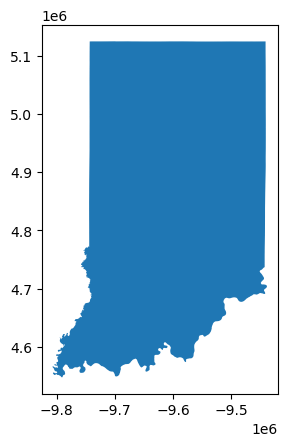

In [6]:
""" Extract the IN row. """
# extract the IN row
in_gdf = states_gdf[states_gdf['STUSPS'] == 'IN']

# plot the IN boundary
in_gdf.plot()

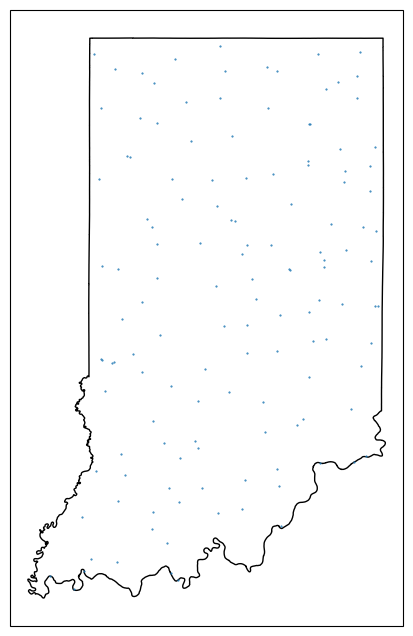

In [7]:
""" Use the IN boundary to clip the snow. """

# convert the in boundary to the same projection as the snow
in_transformed_gdf = in_gdf.to_crs(inventory_50_gpd.crs)

# clip the snow to the IN boundary
in_snow_gdf = gpd.clip(inventory_50_gpd, in_transformed_gdf)

# isolate this to just the SNOW variable
in_snow_gdf = in_snow_gdf[in_snow_gdf.VARIABLE == 'SNOW']

# plot the clipped snow and the state boundary
fig, ax = plt.subplots(subplot_kw=dict(projection=projection), figsize=(12, 8))
in_transformed_gdf.plot(ax = ax, transform = projection, facecolor = 'none', edgecolor = 'black')
in_snow_gdf.plot(ax = ax, transform = projection, marker = '.', markersize = 1)

plt.show()



In [8]:
""" Set the URL template for the GHCN-Daily data. """

# create a function to load the GHCN-Daily data for a station
def load_ghcn_data(station):
    
    url_template = "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/{station}.csv"

    # set the station URL
    url = url_template.format(station = station)

    # load the data for the station
    station_pd = pd.read_csv(url)

    # return the station
    return station_pd

# test on the first station
station = in_snow_gdf.iloc[0].ID
test_pd = load_ghcn_data(station)
test_pd.head()



,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,...,MDSF,MDSF_ATTRIBUTES,WT01,WT01_ATTRIBUTES,WT04,WT04_ATTRIBUTES,WT16,WT16_ATTRIBUTES,WT18,WT18_ATTRIBUTES
0,USC00121998,1922-01-08,37.83333,-87.66667,113.1,"CYPRESS DAM 48, IN US",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,6",NaN,NaN
1,USC00121998,1922-01-13,37.83333,-87.66667,113.1,"CYPRESS DAM 48, IN US",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,6"
2,USC00121998,1922-01-18,37.83333,-87.66667,113.1,"CYPRESS DAM 48, IN US",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,6",NaN,NaN
3,USC00121998,1922-01-21,37.83333,-87.66667,113.1,"CYPRESS DAM 48, IN US",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,",,6",NaN,NaN,NaN,NaN
4,USC00121998,1922-02-01,37.83333,-87.66667,113.1,"CYPRESS DAM 48, IN US",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,6",NaN,NaN


In [9]:
""" Download data for all the stations. """
station_pd_list = []

for station in tqdm(in_snow_gdf.ID):
    
    # load the data for the station
    station_pd = load_ghcn_data(station)
    station_pd_list.append(station_pd)

  0%|          | 0/134 [00:00<?, ?it/s]

/tmp/ipykernel_911105/946505999.py:12: DtypeWarning: Columns (17,19,21,27,31,33,35,37,39,41,43,45,47) have mixed types. Specify dtype option on import or set low_memory=False.
  station_pd = pd.read_csv(url)
/tmp/ipykernel_911105/946505999.py:12: DtypeWarning: Columns (19,21,25,27,29,33,45,47,49,53) have mixed types. Specify dtype option on import or set low_memory=False.
  station_pd = pd.read_csv(url)
/tmp/ipykernel_911105/946505999.py:12: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  station_pd = pd.read_csv(url)
/tmp/ipykernel_911105/946505999.py:12: DtypeWarning: Columns (17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,73,75,77,79,81,83,85,87,89,91,93,97,107,111,113,115,117,119,121,123,125,127,129,131,133,135) have mixed types. Specify dtype option on import or set low_memory=False.
  station_pd = pd.read_csv(url)
/tmp/ipykernel_911105/946505999.py:12: DtypeWarning: Columns (19,23,39,41,43

In [10]:
""" Combine the data into a single dataframe. """
# combine the data into a single dataframe
in_data_pd = pd.concat(station_pd_list)

# save the data to a CSV file with today's date
in_data_pd.to_csv(f"12th_Dec.csv", index = False)

In [11]:
""" Convert the data to a geopandas dataframe. """

# parse the date column
import datetime as dt
in_data_pd.date = pd.to_datetime(in_data_pd.DATE)

# convert the data to a geopandas dataframe
in_data_gpd = gpd.GeoDataFrame(in_data_pd, geometry = gpd.points_from_xy(in_data_pd.LONGITUDE, in_data_pd.LATITUDE), crs = "EPSG:4326")

/tmp/ipykernel_911105/3517375092.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  in_data_pd.date = pd.to_datetime(in_data_pd.DATE)


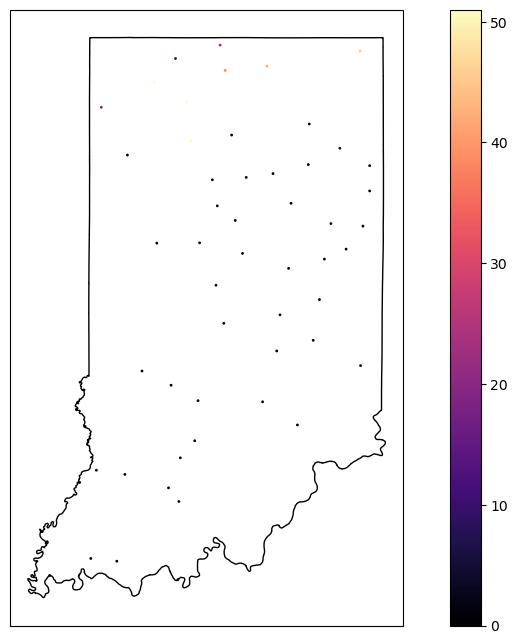

In [12]:
""" Pick a date and plot the snow """
# pick a date
projection = cartopy.crs.PlateCarree()

date = dt.datetime(2022,1,2)
data_correspond = in_data_gpd[in_data_pd.date == date]

# plot the snow
fig, ax = plt.subplots(subplot_kw=dict(projection=projection), figsize=(12, 8))

data_correspond.plot(ax = ax, transform = projection, column = "SNOW", legend = True, cmap = "magma", markersize = 1)

in_transformed_gdf.plot(ax = ax, transform = projection, facecolor = 'none', edgecolor = 'black')

plt.show()

## Breakpoint

If you want to spend class time on your final project, here would be a good place to end the exercise.  Otherwise, I encourage you to keep going.

In [13]:
""" Calculate the total snow each year."""
# sum by year
in_snow_year_pd = in_data_pd.groupby([in_data_pd.date.dt.year, "STATION"])['SNOW'].sum().reset_index()

In [14]:
""" Calculate the trend in snow. """

# calculate the trend in snow
in_trend_pd = in_snow_year_pd.groupby("STATION").apply(lambda x: scipy.stats.linregress(x['DATE'], x['SNOW'])[0]).reset_index()

# get the lat/lon for each station from the inventory
in_trend_pd = in_trend_pd.merge(in_snow_gdf[["ID", "LATITUDE", "LONGITUDE"]], left_on = "STATION", right_on = "ID").drop("ID", axis = 1)

# convert the dataframe to a geodataframe
in_trend_gpd = gpd.GeoDataFrame(in_trend_pd, geometry = gpd.points_from_xy(in_trend_pd.LONGITUDE, in_trend_pd.LATITUDE), crs = "EPSG:4326")

# rename the columns
in_trend_gpd.columns = ["STATION", "TREND", "LATITUDE", "LONGITUDE", "geometry"]

/tmp/ipykernel_911105/4256525281.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  in_trend_pd = in_snow_year_pd.groupby("STATION").apply(lambda x: scipy.stats.linregress(x['DATE'], x['SNOW'])[0]).reset_index()


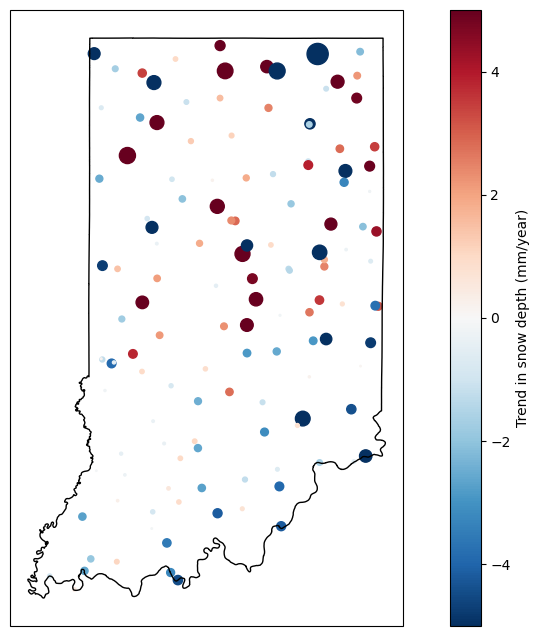

In [15]:
""" Plot the trend in snow. """


fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(projection=projection))

# plot the trends, using the trend magnitude as the color and marker size
in_trend_gpd.plot(ax = ax, transform = projection, column = "TREND", legend = True, cmap = "RdBu_r", vmin = -5, vmax = 5, markersize = abs(in_trend_gpd['TREND']) * 10, legend_kwds={'label': "Trend in snow depth (mm/year)"})

# plot the state boundary
in_transformed_gdf.plot(ax = ax, transform = projection, facecolor = 'none', edgecolor = 'black')

plt.show()


